# Problem Statement: Build a Smart Mutual Fund Advisor

*On top of the Mutual Funds Report, [sourced](https://www.kaggle.com/datasets/dhavalrupapara/mutual-funds-market-dataset) from Kaggle*

---

## Objective  
Create a Gradio-based AI assistant that recommends a mutual fund investment portfolio based on the user's risk and return preferences. The app uses Retrieval-Augmented Generation (RAG) on a structured Mutual Fund product dataset, generating explainable, structured results.

---

## User App (Essential Features)

### Inputs
- **Investment Needs**: Free-form text input  
  *(e.g., “high return portfolio, only from Aditya Birla fund house”)*
  
### Output
- **Suggestion**: A natural language explanation of what's recommended and why
- **Recommended Mutual Funds**: Structured as a list containing:
  - Scheme Name
  - Fund House
---

## Developer-Facing Advanced Settings

Shown under a collapsible **LLM Settings (Advanced)** section in the UI.

### Model & Generation Settings
- **Model Selector**: *select 2 more open-source / closed-source models*
  - GPT OSS 120B (`gpt-oss-120b`)
- **Temperature Slider**: Adjustable between 0 and 2

These settings allow developers to tune how deterministic or creative the model’s responses are.

---

## Backend Setup

### Vector Store and RAG
- **Embedding Model**: Nomic Embed Text via Ollama, or other model of your choice
- **Vector Database**: ChromaDB, or other vector DB of your choice
- **RAG Workflow**:
  1. Load product catalog using `CSVLoader`
  2. Parse and clean fields into `Document` objects with metadata
  3. Generate embeddings and index documents
  4. Perform similarity search based on user preferences
  5. Use an LLM to generate structured output parsed via `PydanticOutputParser`

# Part 1: Implement the Solution

## Setup

In [1]:
import gradio as gr
import pandas as pd
import os
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.output_parsers import PydanticOutputParser
from langchain.schema.output_parser import OutputParserException
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from uuid import uuid4
from langgraph.graph import START, StateGraph, END
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver

C:\Users\syuvr\Downloads\Assignment 2\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
## TODO: Load environment variables and API Keys here
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
print("Groq key loaded:", os.getenv("GROQ_API_KEY") is not None)

Groq key loaded: True


## Defining Components

### Chat Model

In [3]:
## TODO: Model name map for UI Mapping
model_name_map = {
    "GPT-OSS-120B": "openai/gpt-oss-120b",
    ## TODO: Add 2 more models here
    "Qwen3.8-27B": "qwen/qwen3.8-27b",
    "GPT-OSS-20B": "openai/gpt-oss-20b"
}

model_choices = [
    "GPT-OSS-120B (Groq)",
    ## TODO: Add 2 more models here
    "Qwen3.8-27B (Groq)",
    "GPT-OSS-20B (Groq)"
]

In [4]:
## TODO: Model Selector
def get_llm(model_choice, temperature):
    if "Groq" in model_choice:
        return init_chat_model(model_name_map[model_choice.split(" ")[0]], model_provider="groq", temperature = temperature)
    else:
        raise ValueError("Invalid model")

### Embedding Model

In [5]:
## TODO: Create embeddings
## Use: OllamaEmbeddings with llama3.2:1b and pull the model beforehand
## Note: on the newer Ollama version (0.34) llama3.2:1b gives "This server does not support embeddings",
## so I am using nomic-embed-text (the embedding model mentioned in the problem statement) via Ollama instead.
!ollama pull nomic-embed-text

embeddings = OllamaEmbeddings(model="nomic-embed-text")

pulling manifest â ‹ pulling manifest â ™ pulling manifest â ¹ pulling manifest â ¸ pulling manifest â ¼ pulling manifest â ´ pulling manifest â ¦ pulling manifest â § pulling manifest â ‡ pulling manifest â � pulling manifest â ‹ pulling manifest â ™ pulling manifest â ¹ pulling manifest â ¸ pulling manifest â ¼ pulling manifest â ´ pulling manifest â ¦ pulling manifest 
pulling 970aa74c0a90: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–� 274 MB                         
pulling c71d239df917: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�  11 KB                         
pulling ce4a164fc046: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�   17 B                         
pulling 31df23ea7daa: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�  420 B                         
verifying sha256 digest 
writing manifest 
success 


### Vector Store

In [6]:
## TODO: Initialize ChromaDB with a persist directory set
vector_store = Chroma(
    collection_name="mutual_funds",
    embedding_function=embeddings,
    persist_directory="./chroma_mutual_funds_db"
)

## Load and Preprocess Data

In [7]:
# Load and preprocess data
loader = CSVLoader(file_path="mutual_funds_data.csv", source_column="scheme_code")
documents_raw = loader.load()

In [8]:
# Convert page_content string to dict and build metadata
documents = []
for doc in documents_raw:
    try:
        row_data = dict(
            line.split(":", 1) for line in doc.page_content.split("\n") if ":" in line
        )
        row_data = {k.strip(): v.strip() for k, v in row_data.items()}

        ## TODO: Keep Scheme Name, Fund House, Scheme Type, Scheme Category, Net Asset Value and Date in content
        page_text = f"""
        Scheme Name: {row_data['scheme_name']} |
        Fund House: {row_data['fund_house']} |
        Scheme Type: {row_data['scheme_type']} |
        Scheme Category: {row_data['scheme_category']} |
        Net Asset Value: {row_data['net_asset_value']} |
        Date: {row_data['date']}
        """

        ## TODO: Keep Scheme Type, Scheme Category in metadata
        metadata = {
            "Scheme Type": row_data["scheme_type"],
            "Scheme Category": row_data["scheme_category"]
        }

        documents.append(Document(page_content=page_text, metadata=metadata))

    except Exception as e:
        print("Skipping row due to error:", e)

In [9]:
len(documents)

35559

In [10]:
print(documents[0].page_content)


        Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend |
        Fund House: Standard Chartered Mutual Fund |
        Scheme Type: Open Ended Schemes |
        Scheme Category: Income |
        Net Asset Value: 10.7205 |
        Date: 29-05-2008
        


In [11]:
len(documents)

35559

## Store in Vector DB

In [12]:
## Store in Chroma - 1000 rows only for quicker processing - and make sure to add UUIDs
## TODO: Add UUIDs
uuids = [str(uuid4()) for _ in range(1000)]

## TODO: Add documents
# adding in batches of 100, sending all 1000 at once was crashing the Ollama runner on my laptop
for i in range(0, 1000, 100):
    vector_store.add_documents(documents=documents[i:i+100], ids=uuids[i:i+100])

print("Documents in vector store:", vector_store._collection.count())

Documents in vector store: 1000


## Initializing for RAG

### Initialize Retriever

In [13]:
## TODO: Initializer Retriever below
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

# small test to see what comes back
retriever.invoke("low risk debt fund")

[Document(id='4e925954-7b0c-41e1-aeea-106f84a5290d', metadata={'Scheme Category': 'Debt Scheme - Low Duration Fund', 'Scheme Type': 'Open Ended Schemes'}, page_content='\n        Scheme Name: LIC MF Low Duration Fund-Regular Plan-Monthly IDCW |\n        Fund House: LIC Mutual Fund |\n        Scheme Type: Open Ended Schemes |\n        Scheme Category: Debt Scheme - Low Duration Fund |\n        Net Asset Value: 12.1226 |\n        Date: 27-10-2023\n        '),
 Document(id='cb7fb497-d3d4-4df8-9860-d88eec92eb90', metadata={'Scheme Type': 'Open Ended Schemes', 'Scheme Category': 'Debt Scheme - Low Duration Fund'}, page_content='\n        Scheme Name: LIC MF Low Duration Fund-Regular Plan-Growth |\n        Fund House: LIC Mutual Fund |\n        Scheme Type: Open Ended Schemes |\n        Scheme Category: Debt Scheme - Low Duration Fund |\n        Net Asset Value: 35.1561 |\n        Date: 27-10-2023\n        '),
 Document(id='efb06589-70db-4533-9791-8ac1d77b07fa', metadata={'Scheme Category': 

### Define Pydantic Schema

In [14]:
## TODO: Define Pydantic schema with type and description
class MutualFund(BaseModel):
    scheme_name: str = Field(description="Name of the mutual fund scheme")
    fund_house: str = Field(description="Fund house (AMC) that manages the scheme")
    scheme_type: str = Field(description="Type of the scheme, e.g. Open Ended Schemes or Close Ended Schemes")
    scheme_category: str = Field(description="Category of the scheme, e.g. Income, Growth, Debt Scheme - Liquid Fund")

class MutualFundOutput(BaseModel):
    reasoning: str = Field(description="Short natural language explanation of why these schemes were picked for the user")
    schemes: List[MutualFund] = Field(description="List of recommended mutual fund schemes")

parser = PydanticOutputParser(pydantic_object=MutualFundOutput)

### Define Prompt

In [15]:
## TODO: Use ChatPromptTemplate.from_template with fields: preferences, context, format_instructions.
## Make sure no two selected mutual fund schemes fall under the same fund house AND scheme type.

template = ChatPromptTemplate.from_template("""
You are a smart mutual fund advisor. A user has shared their investment preferences and
you are given a list of mutual fund schemes retrieved from our database.

User preferences:
{preferences}

Available mutual fund schemes:
{context}

Instructions:
1. Recommend a small portfolio of schemes (2 to 4) that best match the user's preferences.
2. Only pick schemes from the list above. Do not invent any scheme.
3. Make sure no two selected schemes have the same fund house AND the same scheme type.
4. Explain in simple words why these schemes suit the user.

{format_instructions}
""")

## Creating RAG Pipeline

### Test RAG Pipeline Manually

In [16]:
preference = "I want a low risk investment portfolio."
context_docs = retriever.invoke(preference) ## TODO: Retrieve relevant funds
relevant_text = "\n".join([doc.page_content for doc in context_docs]) ## TODO: Joining the funds
llm = get_llm("GPT-OSS-120B (Groq)", 0.7) ## TODO: Get LLM
chain = template | llm | parser ## TODO: Create a Runnable Sequence with 3 Runnables - template, LLM and Output Parser
input_dict = {"preferences": preference, "context": relevant_text, "format_instructions": parser.get_format_instructions()} ## TODO: Create dictionary with preferences, context and format_instructions
chain.invoke(input_dict).model_dump() ## TODO: Invoke chain and the output of this command should be a dictionary

{'reasoning': 'Both recommended funds are debt‑oriented and focus on short‑term, high‑quality instruments, which makes them suitable for a low‑risk investment profile. The Sundaram Short Term Credit Risk Fund invests in short‑term credit securities, providing stable returns with limited volatility. The Franklin India Low Duration Fund (Quarterly) holds a portfolio of short‑term debt instruments, offering liquidity and low interest‑rate sensitivity. Together they give diversification across two reputable fund houses while staying within the low‑risk, debt‑fund space.',
 'schemes': [{'scheme_name': 'Sundaram Short Term Credit Risk Fund -Dividend',
   'fund_house': 'Sundaram Mutual Fund',
   'scheme_type': 'Open Ended Schemes',
   'scheme_category': 'Debt Scheme - Credit Risk Fund'},
  {'scheme_name': 'Franklin India Low Duration Fund - Quarterly - IDCW',
   'fund_house': 'Franklin Templeton Mutual Fund',
   'scheme_type': 'Open Ended Schemes',
   'scheme_category': 'Debt Scheme - Low Dur

### Define RAG Pipeline Function

In [17]:
# RAG pipeline
def generate_portfolio(model_choice, user_input):
    context_docs = retriever.invoke(user_input["preferences"]) ## TODO: Retrieving relevant funds
    relevant_funds = "\n".join([doc.page_content for doc in context_docs]) ## TODO: Joining the funds
    llm = get_llm(model_choice, user_input["temperature"]) ## TODO: Get the LLM

    #Invoking
    chain = template | llm ## TODO: Create a Runnable Sequence with 2 Runnables - template and LLM
    output = chain.invoke({
        "preferences": user_input["preferences"],
        "context": relevant_funds,
        "format_instructions": parser.get_format_instructions()
    }) ## TODO: Invoke the Runnable Sequence with the preferences, context and format instructions

    #Exception Handling
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None
    return result

# testing the function once before hooking it into the UI
generate_portfolio("GPT-OSS-20B (Groq)", {"preferences": "high return portfolio, only from Aditya Birla fund house", "temperature": 0.7})

MutualFundOutput(reasoning='These two schemes from Aditya Birla Sun Life Mutual Fund offer a balanced high‑return mix. The close‑ended ELSS (Tax Plan 98) gives tax‑advantaged equity exposure and strong historical growth, while the open‑ended Nifty 50 Index Fund tracks the market index for broad equity upside. They come from the same AMC but use different scheme types, satisfying the uniqueness rule.', schemes=[MutualFund(scheme_name='Aditya Birla Tax Plan 98', fund_house='Aditya Birla Sun Life Mutual Fund', scheme_type='Close Ended Schemes', scheme_category='ELSS'), MutualFund(scheme_name='Aditya Birla Sun Life Nifty 50 Index Fund -REGULAR - IDCW', fund_house='Aditya Birla Sun Life Mutual Fund', scheme_type='Open Ended Schemes', scheme_category='Other Scheme - Index Funds')])

## User Interface

In [18]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    result = generate_portfolio(model_choice, user_input)
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [19]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [20]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7900


* To create a public link, set `share=True` in `launch()`.


# Part 2: Implement the RAG pipeline in LangGraph

## Creating Graph

### Define State Class

In [21]:
## TODO: Define State class with preferences, context and answer keys
class State(TypedDict):
    preferences: str
    context: List[Document]
    answer: MutualFundOutput

### Define Nodes

In [22]:
## TODO: Define retrieve node
def retrieve(state: State):
    relevant_funds = retriever.invoke(state["preferences"]) ## TODO: Retrieving relevant mutual funds
    return {"context": relevant_funds} ## TODO: Return the relevant parts of the state: context only

In [23]:
## TODO: Define generate node
def generate(state: State):
    relevant_funds_str = "\n".join([doc.page_content for doc in state["context"]]) ## TODO: Joining the mutual funds

    chain = template | llm_graph ## TODO: Create a Runnable Sequence with 2 Runnables - template and llm_graph (different variable that's defined later)
    output = chain.invoke({
        "preferences": state["preferences"],
        "context": relevant_funds_str,
        "format_instructions": parser.get_format_instructions()
    }) ## TODO: Invoke the Runnable Sequence with the preferences, context and format instructions

    #Exception Handling for Output Parser
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None

    return {"answer": result} ## TODO: Return the relevant parts of the state: answer only

### Build and Compile Graph

In [24]:
## TODO: Build the graph with 2 nodes and 3 edges
graph_builder = StateGraph(State) ## TODO: To add

graph_builder.add_node("retrieve", retrieve) ## TODO: To add
graph_builder.add_node("generate", generate) ## TODO: To add

graph_builder.add_edge(START, "retrieve") ## TODO: To add
graph_builder.add_edge("retrieve", "generate") ## TODO: To add
graph_builder.add_edge("generate", END) ## TODO: To add

In [25]:
#Compile graph
graph = graph_builder.compile()

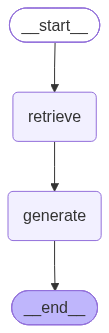

In [26]:
#Visualize graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Test Manually

In [27]:
preferences = "I want a low risk investment portfolio."
llm_graph = get_llm("GPT-OSS-120B (Groq)", 0.7) ## TODO: Get LLM
result = graph.invoke({"preferences": preferences}) ## TODO: Invoke the graph
print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(id='9391778a-c7bd-44bd-86ba-487a4801f489', metadata={'Scheme Category': 'Debt Scheme - Credit Risk Fund', 'Scheme Type': 'Open Ended Schemes'}, page_content='\n        Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend |\n        Fund House: Sundaram Mutual Fund |\n        Scheme Type: Open Ended Schemes |\n        Scheme Category: Debt Scheme - Credit Risk Fund |\n        Net Asset Value: 11.3002 |\n        Date: 29-12-2020\n        '), Document(id='efb06589-70db-4533-9791-8ac1d77b07fa', metadata={'Scheme Category': 'Debt Scheme - Low Duration Fund', 'Scheme Type': 'Open Ended Schemes'}, page_content='\n        Scheme Name: Franklin India Low Duration Fund - Quarterly - IDCW |\n        Fund House: Franklin Templeton Mutual Fund |\n        Scheme Type: Open Ended Schemes |\n        Scheme Category: Debt Scheme - Low Duration Fund |\n        Net Asset Value: 14.7667 |\n        Date: 07-08-2022\n        '), Document(id='e2acfe3c-5be4-43b2-8d18-768c40f53f94', m

## User Interface

In [28]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    llm_graph = get_llm(user_input["model_choice"], user_input["temperature"])
    result = graph.invoke({"preferences": preferences})["answer"]
    
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [29]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [30]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7901


* To create a public link, set `share=True` in `launch()`.
